# Payments EDA

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [6]:
payments = pd.read_csv("../04_Feature_Engineering/Output/order_payments_features.csv")

In [7]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_total_value_per_order,payment_method_count,multiple_payment_methods,max_installments_per_order,installment_payment_flag,average_payment_value_per_transaction
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,99.33,1,0,8,1,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,24.39,1,0,1,0,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,65.71,1,0,1,0,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,107.78,1,0,8,1,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,128.45,1,0,2,1,128.45


In [8]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 11 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   order_id                               103886 non-null  object 
 1   payment_sequential                     103886 non-null  int64  
 2   payment_type                           103886 non-null  object 
 3   payment_installments                   103886 non-null  int64  
 4   payment_value                          103886 non-null  float64
 5   payment_total_value_per_order          103886 non-null  float64
 6   payment_method_count                   103886 non-null  int64  
 7   multiple_payment_methods               103886 non-null  int64  
 8   max_installments_per_order             103886 non-null  int64  
 9   installment_payment_flag               103886 non-null  int64  
 10  average_payment_value_per_transaction  103886 non-null  

In [9]:
payments.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_total_value_per_order,payment_method_count,multiple_payment_methods,max_installments_per_order,installment_payment_flag,average_payment_value_per_transaction
count,103886,103886.000000,103886,103886.000000,103886.000000,103886.000000,103886.000000,103886.000000,103886.000000,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,29,NaN,76795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380,161.155179,1.051855,0.051855,2.887194,0.503369,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064,222.384248,0.221735,0.221735,2.701435,0.499991,216.473375
min,NaN,1.000000,NaN,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000,62.010000,1.000000,0.000000,1.000000,0.000000,57.130000
50%,NaN,1.000000,NaN,1.000000,100.000000,105.200000,1.000000,0.000000,2.000000,1.000000,99.820000
75%,NaN,1.000000,NaN,4.000000,171.837500,176.780000,1.000000,0.000000,4.000000,1.000000,171.510000


In [10]:
payments.isnull().sum()

order_id                                 0
payment_sequential                       0
payment_type                             0
payment_installments                     0
payment_value                            0
payment_total_value_per_order            0
payment_method_count                     0
multiple_payment_methods                 0
max_installments_per_order               0
installment_payment_flag                 0
average_payment_value_per_transaction    0
dtype: int64

In [11]:
payments.duplicated().sum()

0

## 1. Payment Method Analysis

In [12]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [13]:
# Percentage distribution
payment_type_pct = (
    payments["payment_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

payment_type_pct.columns = ["payment_type", "percentage"]

payment_type_pct

,payment_type,percentage
0,credit_card,73.92
1,boleto,19.04
2,voucher,5.56
3,debit_card,1.47
4,not_defined,0.00


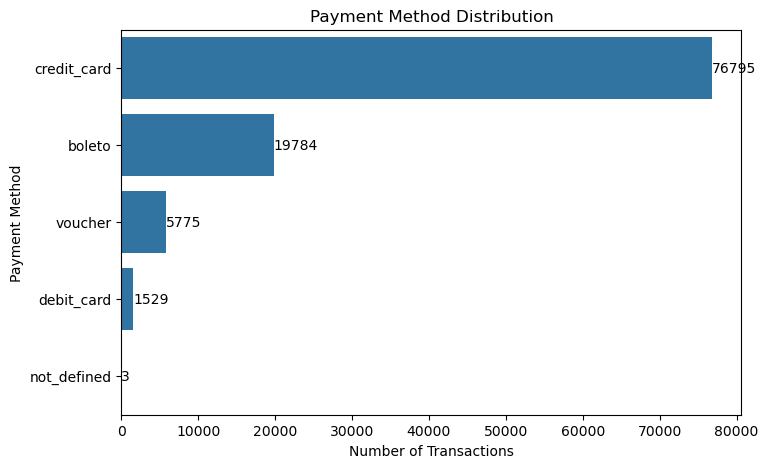

In [14]:
# Count Plot
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=payments,
    y="payment_type",
    order=payments["payment_type"].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Payment Method Distribution")
plt.xlabel("Number of Transactions")
plt.ylabel("Payment Method")

plt.show()

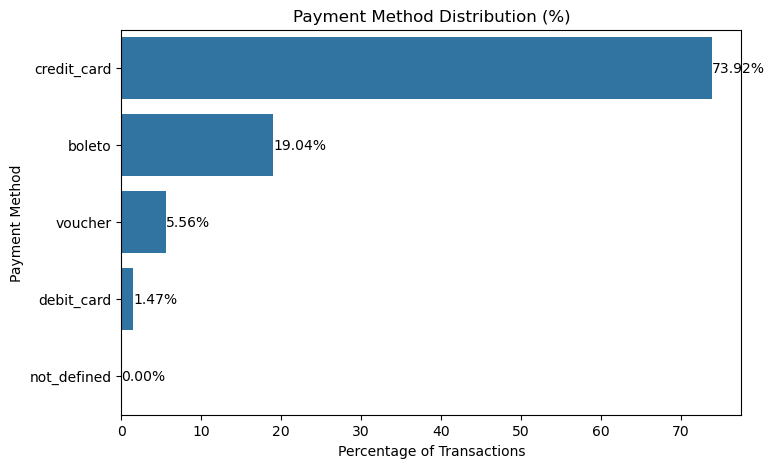

In [15]:
# Percentage Plot 
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=payment_type_pct,
    x="percentage",
    y="payment_type"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Payment Method Distribution (%)")
plt.xlabel("Percentage of Transactions")
plt.ylabel("Payment Method")

plt.show()

## Business Insights
* Credit card support is critical for maintaining customer convenience and minimizing checkout friction.
* Since boleto is also widely used, it should remain a supported payment option to serve customers who prefer offline or bank-based payments.
* Voucher and debit card usage is relatively small and may warrant monitoring rather than aggressive investment.

## 2. Installment Analysis

In [16]:
payments["payment_installments"].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [17]:
installment_pct = (
    payments["payment_installments"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .reset_index()
)

installment_pct.columns = ["installments", "percentage"]

installment_pct

,installments,percentage
0,0,0.00
1,1,50.58
2,2,11.95
3,3,10.07
4,4,6.83
5,5,5.04
6,6,3.77
7,7,1.57
8,8,4.11
9,9,0.62


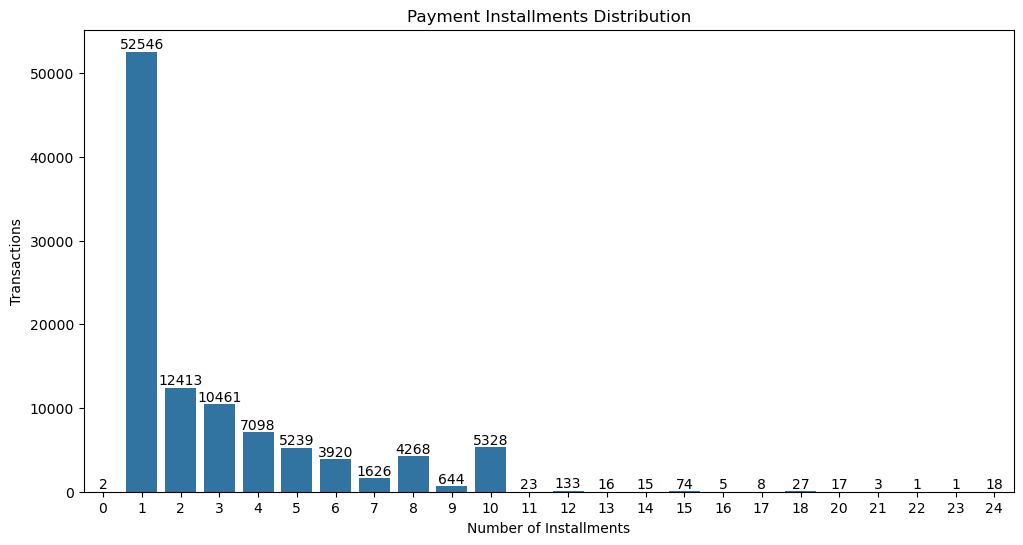

In [18]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=payments,
    x="payment_installments",
    order=sorted(payments["payment_installments"].unique())
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Payment Installments Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Transactions")

plt.show()

### Analysing Installment flag

In [19]:
payments["installment_payment_flag"].value_counts()

installment_payment_flag
1    52293
0    51593
Name: count, dtype: int64

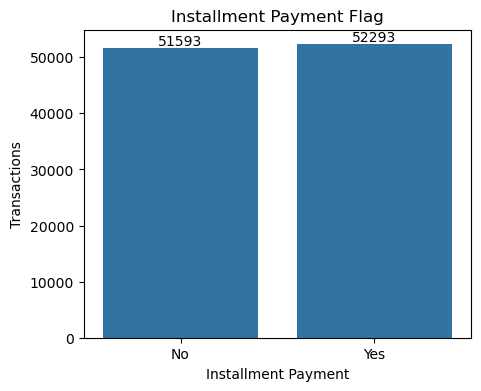

In [20]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=payments,
    x="installment_payment_flag"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Installment Payment Flag")
plt.xlabel("Installment Payment")
plt.ylabel("Transactions")

plt.xticks([0,1], ["No", "Yes"])

plt.show()

## Business Insights
* Customers exhibit a balanced preference between one-time payments and installment financing.
* Offering installment options appears to be an important feature that supports purchasing decisions.
* Extremely long installment plans are uncommon, suggesting that most financing needs are satisfied within a relatively small number of installments.

## 3. Payment Value Analysis

In [22]:
# Helper Function 
def analyze_numeric_feature(df, column, bins=50):
    """
    Performs basic EDA for a numeric feature.
    """

    print("=" * 60)
    print(f"EDA for: {column}")
    print("=" * 60)

    # Summary Statistics
    print("\nSummary Statistics\n")
    print(df[column].describe())

    # Missing Values
    print("\nMissing Values\n")
    print(df[column].isnull().sum())

    # Histogram
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,

        x=column,
        bins=bins,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 2))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot of {column}")


    plt.show()

    # Largest Values
    print("\nTop 10 Largest Values\n")
    print(df[column].nlargest(10))

    # Smallest Values
    print("\nTop 10 Smallest Values\n")
    print(df[column].nsmallest(10))

EDA for: payment_value

Summary Statistics

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

Missing Values

0


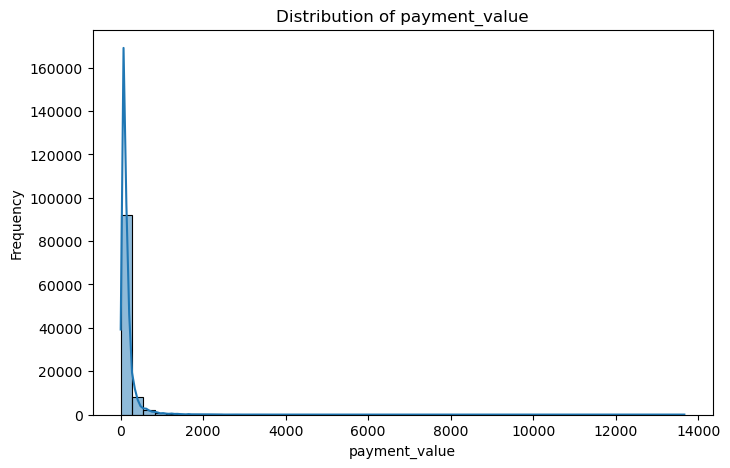

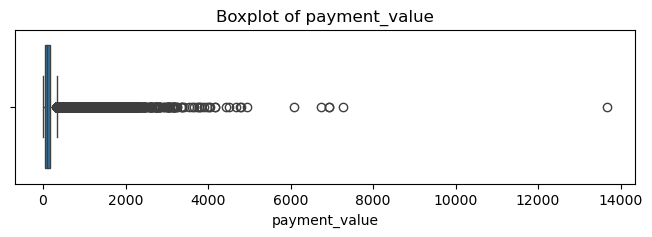


Top 10 Largest Values

52107    13664.08
34370     7274.88
41419     6929.31
49581     6922.21
85539     6726.66
62409     6081.54
43232     4950.34
70320     4809.44
6440      4764.34
67546     4681.78
Name: payment_value, dtype: float64

Top 10 Smallest Values

19922     0.00
36822     0.00
43744     0.00
51280     0.00
57411     0.00
62674     0.00
77885     0.00
94427     0.00
100766    0.00
810       0.01
Name: payment_value, dtype: float64


In [23]:
analyze_numeric_feature(payments, "payment_value")

EDA for: payment_total_value_per_order

Summary Statistics

count    103886.000000
mean        161.155179
std         222.384248
min           0.000000
25%          62.010000
50%         105.200000
75%         176.780000
max       13664.080000
Name: payment_total_value_per_order, dtype: float64

Missing Values

0


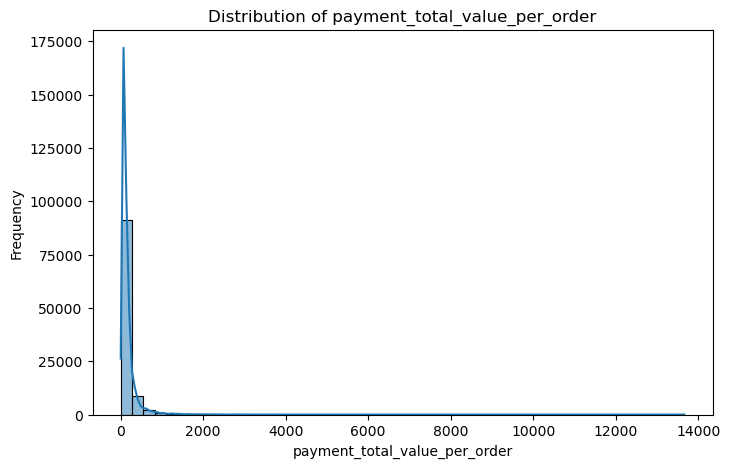

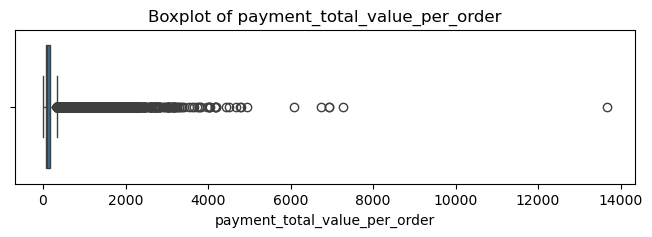


Top 10 Largest Values

52107    13664.08
34370     7274.88
41419     6929.31
49581     6922.21
85539     6726.66
62409     6081.54
43232     4950.34
70320     4809.44
6440      4764.34
67546     4681.78
Name: payment_total_value_per_order, dtype: float64

Top 10 Smallest Values

51280      0.00
57411      0.00
94427      0.00
90525      9.59
103036     9.59
99451     10.07
683       10.89
24233     11.56
73345     11.56
76590     11.62
Name: payment_total_value_per_order, dtype: float64


In [24]:
analyze_numeric_feature(payments, "payment_total_value_per_order")

EDA for: average_payment_value_per_transaction

Summary Statistics

count    103886.000000
mean        154.100380
std         216.473375
min           0.000000
25%          57.130000
50%          99.820000
75%         171.510000
max       13664.080000
Name: average_payment_value_per_transaction, dtype: float64

Missing Values

0


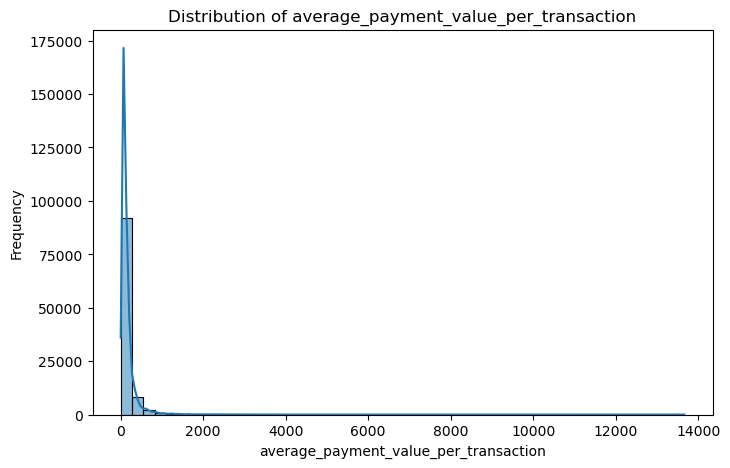

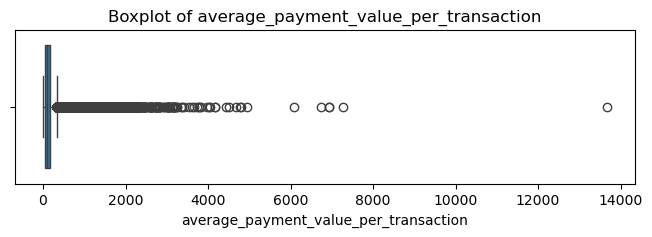


Top 10 Largest Values

52107    13664.08
34370     7274.88
41419     6929.31
49581     6922.21
85539     6726.66
62409     6081.54
43232     4950.34
70320     4809.44
6440      4764.34
67546     4681.78
Name: average_payment_value_per_transaction, dtype: float64

Top 10 Smallest Values

51280    0.0000
57411    0.0000
94427    0.0000
4399     1.7375
7441     1.7375
17037    1.7375
24976    1.7375
35665    1.7375
54550    1.7375
57136    1.7375
Name: average_payment_value_per_transaction, dtype: float64


In [25]:
analyze_numeric_feature(payments, "average_payment_value_per_transaction")

## Business Insights
* Most customer purchases are relatively modest in value, while a small number of premium orders contribute disproportionately to transaction values.
* High-value orders may require additional fraud monitoring, insurance, or special handling.
* Investigating zero-value payments can improve understanding of exceptional payment scenarios.

## 4. Multiple Payment Methods

In [26]:
payments["payment_method_count"].value_counts().sort_index()

payment_method_count
1    98499
2     5387
Name: count, dtype: int64

In [27]:
payments["multiple_payment_methods"].value_counts()

multiple_payment_methods
0    98499
1     5387
Name: count, dtype: int64

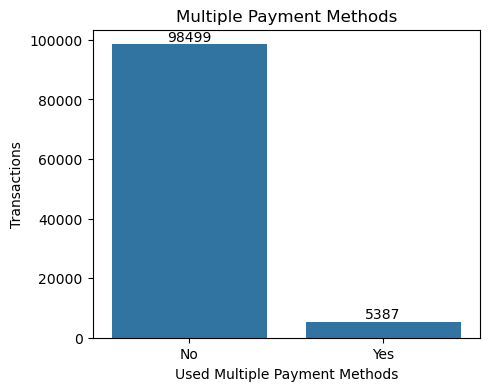

In [28]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=payments,
    x="multiple_payment_methods"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Multiple Payment Methods")
plt.xlabel("Used Multiple Payment Methods")
plt.ylabel("Transactions")

plt.xticks([0,1], ["No", "Yes"])

plt.show()

## Business Insights
* The checkout experience appears straightforward for most customers, with little need to split payments across methods.
* Multi-method payments are uncommon but could represent higher-value purchases or customers combining vouchers with other payment methods.

## Overall Business Insights
* Maintaining reliable credit card and boleto payment infrastructure is essential, as together they account for the vast majority of transactions.
* Installment payments are a key part of customer purchasing behavior and likely support higher-value purchases.
* The simplicity of the payment process suggests a low level of checkout complexity for most customers.